In [1]:
# %matplotlib widget

import npoly2d as n2
import metric_mesh as mm
import diffgeo_nd as dn

import numpy as np
import yaml
import sympy as sym
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.patches import Ellipse, Rectangle

from IPython.display import clear_output


In [2]:
import importlib
importlib.reload(mm)

<module 'metric_mesh' from '/Users/albertxu/liie/metric_mesh.py'>

In [3]:
N = 100

# Arm configuration
_gamma = np.zeros((N, 3))
_gamma[:, 0] = np.linspace(0, 1, N)  # Straight arm along x-axis
gamma = np.array([n2.rho(gi) for gi in _gamma])

sx = sym.symbols('t')
sfx = ''  # [1,1,0] -> '', [1,1,1] -> '1'
if sfx == '':
    gab = np.diag([1, 1, 0])
elif sfx == '1':
    gab = np.diag([1, 1, 1])

with open(f'_orthopoly{sfx}.yaml', 'r') as f:
    polys_string = yaml.safe_load(f)
pp = [sym.sympify(ps) for ps in polys_string]
print('loaded bases')

def eval_poly(x):
    return np.array([pi.subs({sx: x}) for pi in pp]).astype(float)
tt = np.linspace(0, 1, 100)
npoly = np.array([eval_poly(ti) for ti in tt])

bases = np.zeros((npoly.shape[1], N, 3))
for i in range(npoly.shape[1]):
    bases[i, :, 2] = npoly[:, i]

def metric(xx):
    x, y = xx
    gamma = n2.shape_exp(x * bases[0] + y * bases[1])
    g00 = n2.inner_product(gamma, gab, bases[0], bases[0])
    g01 = n2.inner_product(gamma, gab, bases[0], bases[1])
    g11 = n2.inner_product(gamma, gab, bases[1], bases[1])
    # print(g01, n2.inner_product(gamma, gab, bases[1], bases[0]))
    return np.array([[g00, g01], [g01, g11]])

loaded bases


In [9]:
def delta_coeffs(gamma, gab, basis):
    t, s, x = sym.symbols('t s x')

    coeffs = []
    for i, bi in enumerate(basis):
        xi = sym.Matrix([0, 0, bi])
        gd1 = Ad(gamma(s)).inv() @ sym.integrate(Ad(gamma(t)) @ xi, (t, 0, s))
        gd2_a = sym.Matrix([0, 0, 0])     # Valid [0, x]
        gd2_b = sym.Matrix([0, s - x, 1]) # Valid [x, 1]

        # Integral_0^a [gd1 . gd2] = Int_x^1 [gd1 . gd2_b]
        coef = sym.integrate((gd1.T @ gab @ gd2_b)[0, 0], (s, x, 1))
        coeffs.append(sym.simplify(coef))
    return coeffs

In [10]:
t = sym.symbols('t')
def gamma(t): return rho(t, 0, 0)

delta_coeffs(gamma, gab, npoly)

ValueError: expecting list of lists

(np.float64(-0.35500651254899496),
 np.float64(0.06490618979872192),
 np.float64(-0.007101134422495336),
 np.float64(0.14912382287240203))

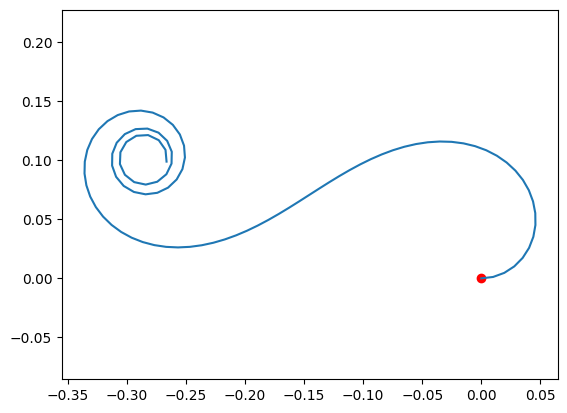

In [7]:
xi1 = np.zeros((N, 3))
xi1[:,2] = npoly[:,0]

xi2 = np.zeros((N, 3))
xi2[:,2] = npoly[:,1]

gam = n2.shape_exp(.5*xi1  -.8*xi2)
plt.scatter(0, 0, c='r')
plt.plot(gam[:,0,2], gam[:,1,2])
plt.axis('equal')

In [4]:
dn.compute_ricci_curvature([0, 0], metric) / 2

np.float64(20.041548951006533)

In [5]:
def metric2(x, y):
    gamma = n2.shape_exp(x * bases[0] + y * bases[1])
    g00 = n2.inner_product(gamma, gab, bases[0], bases[0])
    g01 = n2.inner_product(gamma, gab, bases[0], bases[1])
    g11 = n2.inner_product(gamma, gab, bases[1], bases[1])
    # print(g01, n2.inner_product(gamma, gab, bases[1], bases[0]))
    return np.array([[g00, g01], [g01, g11]])

In [6]:
mm.compute_gaussian_curvature(0, 0, metric2)

np.float64(20.041549087555765)

In [15]:
def box_mesh(ll, N=100):
    mesh_points = np.array([
        [-ll, -ll],
        [ ll, -ll],
        [-ll,  ll],
        [ ll,  ll]
    ])
    mesh_simplices = np.array([
        [0, 1, 2],
        [1, 3, 2]
    ])
    eps = 1e-5

    mesh_domain = {'type': 'mesh', 'points': mesh_points, 'simplices': mesh_simplices}
    samples, volume = dn.montecarlo_integration_samples(mesh_domain, N)

    integrand_values = []
    for sample in tqdm(samples):
        R = dn.compute_ricci_curvature(sample, metric, eps)
        g = metric(sample)
        det_g = np.linalg.det(g)
        sqrt_det_g = np.sqrt(np.abs(det_g))  # Use abs for robustness
        integrand_values.append(R * sqrt_det_g)

    integrand_values = np.array(integrand_values)

    # Monte Carlo estimate: I ≈ V * <f>
    mean_integrand = np.mean(integrand_values)
    std_integrand = np.std(integrand_values)
    
    integral = volume * mean_integrand
    error_estimate = volume * std_integrand / np.sqrt(len(integrand_values))
    return integral, error_estimate

In [22]:
ls = np.linspace(.1, 1, 20)
ys = []
errs = []
for li in ls:
    print(f'L={li}')
    integ, err = box_mesh(li, 500)
    ys.append(integ)
    errs.append(err)
    print(f'{integ} +/- {err}')

L=0.1


100%|████████████████████████████████████████████████████████████████████| 500/500 [03:39<00:00,  2.28it/s]


1.0549002007906108 +/- 0.017610516782098868
L=0.1473684210526316


100%|████████████████████████████████████████████████████████████████████| 500/500 [03:34<00:00,  2.33it/s]


1.6775855343101786 +/- 0.04734415665226474
L=0.19473684210526315


...

7.127480576386952 +/- 1.4055476577888517
L=0.9526315789473684


100%|████████████████████████████████████████████████████████████████████| 500/500 [03:39<00:00,  2.28it/s]


4.153085701742093 +/- 1.4096092684758443
L=1.0


100%|████████████████████████████████████████████████████████████████████| 500/500 [03:39<00:00,  2.28it/s]

5.258128062172958 +/- 1.453371781836884


In [34]:
for i in range(15, 20):
    li = ls[i]
    print(f'L={li}')
    integ, err = box_mesh(li, 1000)
    ys[i] = integ
    errs[i] = err
    print(f'{integ} +/- {err}')

L=0.8105263157894737


100%|██████████████████████████████████████████████████████████████████| 1000/1000 [07:18<00:00,  2.28it/s]


5.586125652030588 +/- 0.8344032024439366
L=0.8578947368421053


100%|██████████████████████████████████████████████████████████████████| 1000/1000 [07:21<00:00,  2.26it/s]


8.105808172291475 +/- 0.9791231157612872
L=0.9052631578947369


...

5.153096913926394 +/- 0.889045079030882
L=0.9526315789473684


100%|██████████████████████████████████████████████████████████████████| 1000/1000 [07:22<00:00,  2.26it/s]


5.2448052129015 +/- 0.9961938247130844
L=1.0


100%|██████████████████████████████████████████████████████████████████| 1000/1000 [07:29<00:00,  2.23it/s]

7.017559147443914 +/- 1.12114700895986


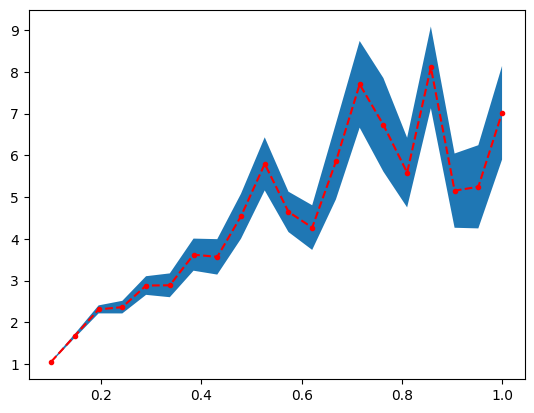

In [46]:
ys = np.array(ys)
plt.plot(ls, ys, 'r.--')
plt.fill_between(ls, ys-errs, ys+errs)

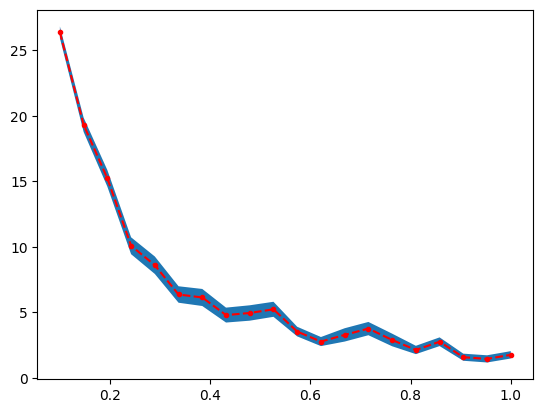

In [53]:
plt.plot(ls, ys / (ls**2) / 4, 'r.--')
plt.fill_between(ls, (ys-errs) / (ls**2) / 4, (ys+errs) / (ls**2) / 4)

In [11]:
# Create a simple 2D triangular mesh (unit square divided into 2 triangles)
ll = .1
mesh_points = np.array([
    [-ll, -ll],
    [ ll, -ll],
    [-ll,  ll],
    [ ll,  ll]
])
mesh_simplices = np.array([
    [0, 1, 2],
    [1, 3, 2]
])
eps = 1e-5

mesh_domain = {'type': 'mesh', 'points': mesh_points, 'simplices': mesh_simplices}
samples, volume = dn.montecarlo_integration_samples(mesh_domain, 100)
# integral_mesh, error_mesh = dn.integrate_ricci_scalar(metric, mesh_domain, num_samples=5000, eps=1e-6)


In [13]:
integrand_values = []
for sample in tqdm(samples[:100]):
    R = dn.compute_ricci_curvature(sample, metric, eps)
    g = metric(sample)
    det_g = np.linalg.det(g)
    sqrt_det_g = np.sqrt(np.abs(det_g))  # Use abs for robustness
    integrand_values.append(R * sqrt_det_g)


100%|████████████████████████████████████████████████████████████████████| 100/100 [00:43<00:00,  2.32it/s]


In [14]:
integrand_values = np.array(integrand_values)

# Monte Carlo estimate: I ≈ V * <f>
mean_integrand = np.mean(integrand_values)
std_integrand = np.std(integrand_values)

integral = volume * mean_integrand
error_estimate = volume * std_integrand / np.sqrt(len(integrand_values))
integral, error_estimate

(np.float64(1.0267757561763873), np.float64(0.0406638000351504))

In [84]:
center = [0, 0]

thetas = np.linspace(0, 2 * np.pi, 16, endpoint=False)
geodesics = []
for theta in tqdm(thetas):
    direction = np.array([np.cos(theta), np.sin(theta)])
    geodesic_points = mm.compute_geodesic(center, direction, metric, length=0.5, num_points=20)
    geodesics.append(geodesic_points)


100%|██████████████████████████████████████████████████████████████████████| 16/16 [02:11<00:00,  8.19s/it]


(np.float64(-0.7619545006150645),
 np.float64(3.779679330327648),
 np.float64(-0.250016813991786),
 np.float64(1.0729579486915248))

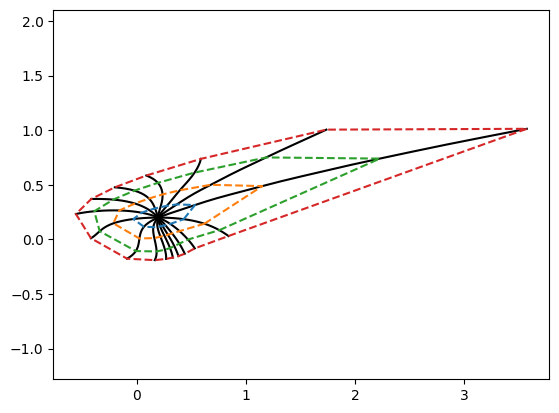

In [81]:
for traji in geodesics:
    plt.plot(*traji.T, c='k')

for ix in [5, 10, 15, 19]:
    circle = np.array(geodesics)[:, ix]
    circle = np.r_[circle, circle[:1]]  # close loop
    plt.plot(*circle.T, '--')
plt.axis('equal')

(-0.5, 0.5)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


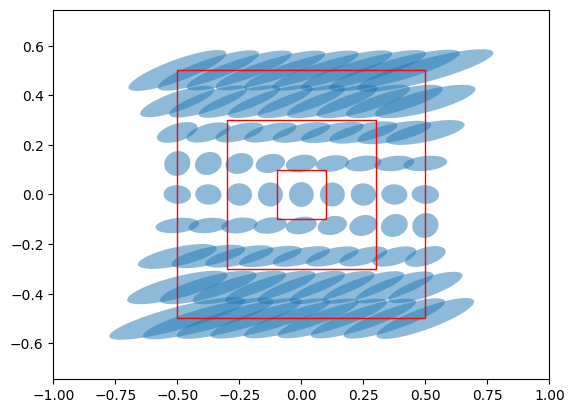

In [50]:
def draw_ellipse(cov, center, ax, n_std=2, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=(x,y), width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

xx = np.linspace(-.5, .5, 9)
ax = plt.gca()
coords = []
for i in range(len(xx)):
    for j in range(len(xx)):
        x, y = xx[i], xx[j]
        coords.append((x, y))
        draw_ellipse(np.linalg.inv(metric2(x, y)), (x, y), ax, .05, alpha=.5)

# plt.scatter(*np.array(coords).T, s=1, c='k')
# for traji in geodesics:
#     plt.plot(*traji.T, c='k')

# for ix in [5, 10, 15, 19]:
#     circle = np.array(geodesics)[:, ix]
#     circle = np.r_[circle, circle[:1]]  # close loop
#     plt.plot(*circle.T, '--')

ll = .1
mesh_points = np.array([
    [-ll, -ll],
    [ ll, -ll],
    [-ll,  ll],
    [ ll,  ll]
])
rect = Rectangle(mesh_points[0], 2*ll, 2*ll, edgecolor='red', facecolor='none')
ax.add_patch(rect)

ll = .3
mesh_points = np.array([
    [-ll, -ll],
    [ ll, -ll],
    [-ll,  ll],
    [ ll,  ll]
])
rect = Rectangle(mesh_points[0], 2*ll, 2*ll, edgecolor='red', facecolor='none')
ax.add_patch(rect)

ll = .5
mesh_points = np.array([
    [-ll, -ll],
    [ ll, -ll],
    [-ll,  ll],
    [ ll,  ll]
])
rect = Rectangle(mesh_points[0], 2*ll, 2*ll, edgecolor='red', facecolor='none')
ax.add_patch(rect)

plt.axis('equal')
plt.xlim(-1, 1)
plt.ylim(-.5, .5)

In [4]:
xx = np.linspace(-1, 1, 30)
yy = np.linspace(-.6, .6, 18)
# np.meshgrid(xx, yy)

vals = []
for yi in tqdm(yy):
    rowi = []
    for xi in xx:
        v = mm.compute_gaussian_curvature(xi, yi, metric)
        rowi.append(v)
    vals.append(rowi)
vals = np.array(vals)

 17%|███████████▊                                                           | 3/18 [00:39<03:18, 13.25s/it]


KeyboardInterrupt: 

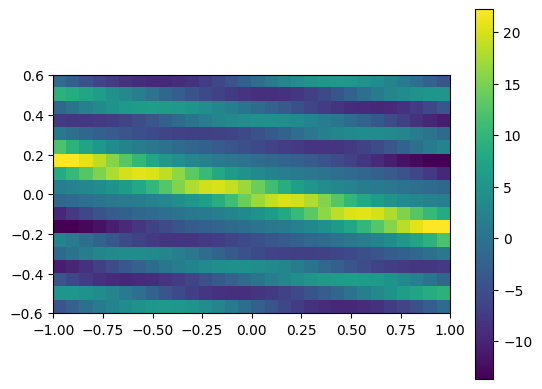

In [73]:
plt.imshow(vals, extent=[xx[0], xx[-1], yy[0], yy[-1]], origin='lower')
plt.colorbar()

In [77]:
traj = mm.compute_geodesic(
    [0, .4],
    [-1, 0],
    metric, length=1., num_points=40)

# traj = np.linspace([0, .4], [0, -.4], 20)

In [75]:
traj.shape

(40, 2)

In [83]:
import ipywidgets as widgets

out = widgets.Output()

# traj = np.array(geodesics)[9]
traj = np.array(geodesics)[12]
@widgets.interact(ix=(0, len(traj) - 1, 1))
def f(ix=len(traj) // 2):
    c1, c2 = traj[ix]
    gamma = n2.shape_exp(c1 * bases[0] + c2 * bases[1])
    xl = [0, 0]
    
    with out:
        clear_output(wait=True)
        plt.subplot(211)
        plt.plot(*traj.T)
        plt.scatter(*traj[ix])
        plt.axis('equal')

        ax = plt.subplot(212)
        ax.plot(gamma[:, 0, 2], gamma[:, 1, 2])
        ax.set_aspect('equal')
        ax.set_xlim(-.3, 1.2)
        ax.set_ylim(-.3, .6)
        xl, yl = plt.xlim(), plt.ylim()
    # print((yl[1] - yl[0]) / (xl[1] - xl[0]))
    # print(xl)


interactive(children=(IntSlider(value=10, description='ix', max=19), Output()), _dom_classes=('widget-interact…

In [14]:
def hyperbolic_metric(x, y):
    scale = (1 - (x**2 + y**2)) ** 2
    return 4 * np.eye(2) / scale

In [16]:
print(mm.compute_christoffel_symbols(.4, 0, hyperbolic_metric))
print(mm.compute_gaussian_curvature(.3, .2, hyperbolic_metric))

[[[ 0.95238095  0.        ]
  [ 0.         -0.95238095]]

 [[ 0.          0.95238095]
  [ 0.95238095  0.        ]]]
-1.0000000566291416


In [54]:
th = np.linspace(0, 2*np.pi, 500)

In [58]:
start = np.array([0, .5])
v = np.array([1, 1])
brr = mm.compute_geodesic(start, v, hyperbolic_metric, length=4.)
brr2 = mm.compute_geodesic(start, -v, hyperbolic_metric, length=4.)

(np.float64(-1.0999791907454364),
 np.float64(1.099999009083116),
 np.float64(-1.0999945499436368),
 np.float64(1.0999945499436368))

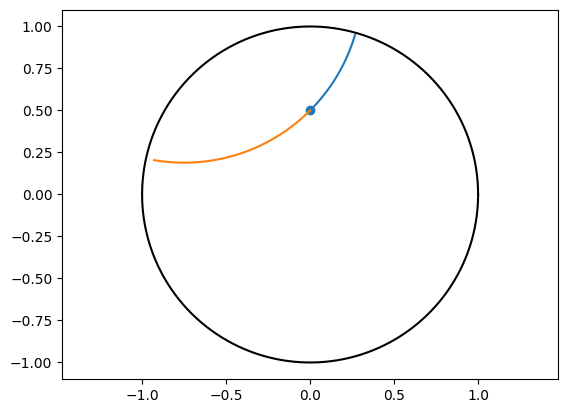

In [59]:
plt.plot(np.cos(th), np.sin(th), c='k')

plt.plot(*brr.T)

plt.plot(*brr2.T)
plt.scatter(*start)
plt.axis('equal')